<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Сегментация изображений</b></h3>


В этом задании вам предстоит решить задачу сегментации медицинских снимков. Домашнее задание можно разделить на следующие части:

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]
* Мир других лоссов! [2]
  * Dice Loss [1]
  * Focal Loss [1]
  * BONUS: лосс из статьи [5]
* Новая модель! [2]
  * UNet [2]


**Максимальный балл:** 10 баллов.

Также для студентов желающих еще более углубиться в задачу предлагается решить бонусное задание, которое даст дополнительные 5 баллов. BONUS задание необязательное.


# Загрузка данных

1. Для начала мы скачаем датасет: [ADDI project](https://www.fc.up.pt/addi/ph2%20database.html).

<table><tr><td>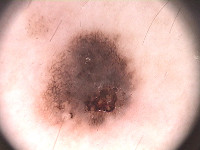</td><td>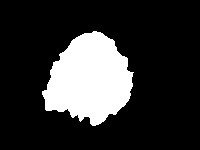</td></tr></table>

2. Разархивируем .rar файл.
3. Обратите внимание, что папка  `PH2 Dataset images` должна лежать там же где и ipynb notebook.

Это фотографии двух типов **поражений кожи:** меланома и родинки.
В данном задании мы не будем заниматься их классификацией, а будем **сегментировать** их.

In [78]:
!gdown 1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql

Downloading...
From (original): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql
From (redirected): https://drive.google.com/uc?id=1T_RPkPP0jeWwK8L1UrmBw8V30eD7v6Ql&confirm=t&uuid=f38569fd-795b-46bf-96f2-254d769a6a7e
To: /content/PH2Dataset.rar
100% 162M/162M [00:01<00:00, 161MB/s]


In [79]:
get_ipython().system_raw("unrar x PH2Dataset.rar")

Стуктура датасета у нас следующая:

    IMD_002/
        IMD002_Dermoscopic_Image/
            IMD002.bmp
        IMD002_lesion/
            IMD002_lesion.bmp
        IMD002_roi/
            ...
    IMD_003/
        ...
        ...

 Здесь `X.bmp` — изображение, которое нужно сегментировать, `X_lesion.bmp` — результат сегментации.

Для загрузки датасета можно использовать skimage: [`skimage.io.imread()`](https://scikit-image.org/docs/dev/api/skimage.io.html)

In [80]:
images = []
lesions = []
from skimage.io import imread
import os
root = 'PH2Dataset'

for root, dirs, files in os.walk(os.path.join(root, 'PH2 Dataset images')):
    if root.endswith('_Dermoscopic_Image'):
        images.append(imread(os.path.join(root, files[0])))
    if root.endswith('_lesion'):
        lesions.append(imread(os.path.join(root, files[0])))

Изображения имеют разные размеры. Давайте изменим их размер на $256\times256 $ пикселей. Для изменения размера изображений можно использовать [`skimage.transform.resize()`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize).
Эта функция также автоматически нормализует изображения в диапазоне $[0,1]$.


In [81]:
from skimage.transform import resize
size = (256, 256)
X = [resize(x, size, mode='constant', anti_aliasing=True,) for x in images]
Y = [resize(y, size, mode='constant', anti_aliasing=False) > 0.5 for y in lesions]

In [82]:
import numpy as np
X = np.array(X, np.float32)
Y = np.array(Y, np.float32)
print(f'Loaded {len(X)} images')

Loaded 200 images


Чтобы убедиться, что все корректно, мы нарисуем несколько изображений

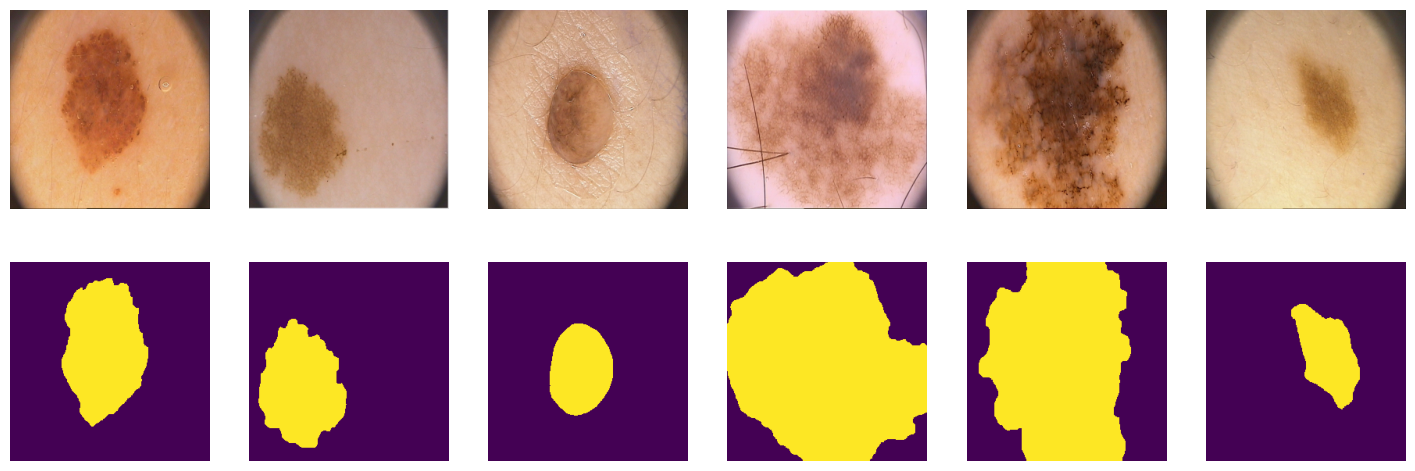

In [83]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

plt.figure(figsize=(18, 6))
for i in range(6):
    plt.subplot(2, 6, i+1)
    plt.axis("off")
    plt.imshow(X[i])

    plt.subplot(2, 6, i+7)
    plt.axis("off")
    plt.imshow(Y[i])
plt.show();

Разделим наши 200 картинок на 100/50/50
 для обучения, валидации и теста соответственно

In [84]:
ix = np.random.choice(len(X), len(X), False)
tr, val, ts = np.split(ix, [100, 150])

In [85]:
print(len(tr), len(val), len(ts))

100 50 50


## PyTorch DataLoader

In [86]:
from torch.utils.data import DataLoader
batch_size = 25
train_dataloader = DataLoader(list(zip(np.rollaxis(X[tr], 3, 1), Y[tr, np.newaxis])),
                     batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(list(zip(np.rollaxis(X[val], 3, 1), Y[val, np.newaxis])),
                      batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(list(zip(np.rollaxis(X[ts], 3, 1), Y[ts, np.newaxis])),
                     batch_size=batch_size, shuffle=True)

In [87]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Метрика

## IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Что будет являться пересечением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

In [88]:
# !pip install torchmetrics

In [89]:
from torchmetrics import JaccardIndex

iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

# Построй свой первый бейзлайн!

Итак, загрузка файлов, код датасета и даталоадера написана за вас. Метрика IoU написана за вас! Вам остается написать лосс, модель и функции обучения и теста модели.

* Построй свой первый бейзлайн! [6]
  * BCE Loss [2]
  * SegNet [2]
  * Train [1]
  * Test [1]

## BCE Loss [2 балла]

Популярным лоссом для бинарной сегментации является *бинарная кросс-энтропия*, которая задается следующим образом:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

где $y$ это  таргет желаемого результата и $\hat y$ является выходом модели. $\sigma$ - это [*логистическая* функция](https://en.wikipedia.org/wiki/Sigmoid_function), который преобразует действительное число $\mathbb R$ в вероятность $[0,1]$.

Однако эта потеря страдает от проблем численной нестабильности. Самое главное, что $\lim_{x\rightarrow0}\log(x)=\infty$ приводит к неустойчивости в процессе оптимизации. Рекомендуется посмотреть следующее [упрощение](https://www.tensorflow.org/api_docs/python/tf/nn/sigmoid_cross_entropy_with_logits). Эта функция эквивалентна первой и не так подвержена численной неустойчивости:

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

### Вывод численно стабильной формулы BCE лосса [1 балл]



Выведите из формулы [1] формулу [2]:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right] \space [1]$$

$$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right) \space [2]$$

Не забываем, что здесь $\hat y_i$ - это логиты сети, не вероятности и не лейблы.

**Ответ:** Нужно расписать сигмоиду и логарифм произведения
\begin{aligned}
\mathcal L_{BCE} &= -y\log\sigma(\hat y) - (1-y)\log(1-\sigma(\hat y)) \\
&= y \log(1 + e^{-\hat y}) + (1-y)\hat y + (1-y)\log(1 + e^{-\hat y}) \\
&= \hat y - y\hat y + \log(1 + e^{-\hat y})
\end{aligned}

### Реализуйте в коде оба варианта лосса [1 балл]

Реализуйте следующие функции:

*   `bce_true()` - честная прямая реализация лосса с формулой $$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$
*   `bce_loss()` - реализация формулы, которую мы вывели $$\mathcal L_{BCE} = \hat y - y\hat y + \log\left(1+\exp(-\hat y)\right).$$

И сравните результаты функций с реализацией Pytorch:
*   `bce_torch()`
*   `bce_torch_with_logits()`

In [90]:
import torch.nn.functional as F
import torch.nn as nn

In [91]:
bce_torch = nn.BCELoss(reduction='sum') # (sigmoid(y_pred), y_real)
bce_torch_with_logits = nn.BCEWithLogitsLoss(reduction='sum')

In [92]:
def bce_loss(y_pred, y_real):
  return torch.sum(y_pred - y_real*y_pred + torch.log1p(torch.exp(-y_pred)))

def bce_true(y_pred, y_real):
  return torch.sum(-(y_real * torch.log(torch.sigmoid(y_pred)) + (1 - y_real) * torch.log(1 - torch.sigmoid(y_pred))))

Проверим корректность работы на простом примере

In [93]:
y_pred = torch.randn(3, 2, requires_grad=False)
y_true = torch.rand(3, 2, requires_grad=False)

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true)}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true)}')


BCE loss from scratch bce_loss = 4.20578670501709
BCE loss честно посчитанный = 4.20578670501709
BCE loss from torch bce_torch = 4.20578670501709
BCE loss from torch with logits bce_torch = 4.205786228179932


Инструкции `assert` в Python — это булевы выражения, которые проверяют, является ли условие истинным (`True`). Внизу в коде мы проверяем функция `bce_loss()` выдает тот же результат, что и функция из Pytorch или нет. Если равенства не будет, что будет означать, что результаты функций не совпадают, а значит вы неправильно реализовали фукнцию `bce_loss()`, `assert` возвратит ошибку.

Функция `numpy.isclose()` используется для сравнения двух чисел с учётом допустимой погрешности. Она особенно полезна при работе с числами с плавающей точкой, где точное сравнение может быть проблематичным из-за ограничений представления таких чисел в компьютере.

Как она работает?

`numpy.isclose(a, b, rtol=1e-05, atol=1e-08) `принимает два числа (`a` и `b`) и сравнивает их, учитывая относительную и абсолютную погрешность. Если разница между двумя числами меньше заданного порога, функция возвращает `True`, иначе — `False`.

Параметры:

    rtol: Относительная погрешность (по умолчанию 1e-05). Используется для определения разницы относительно большего значения.
    atol: Абсолютная погрешность (по умолчанию 1e-08). Определяет минимальную разницу, которую следует учитывать.

Мы будем использовать `assert` и `numpy.isclose()` для проверки корректности нашего кода.

In [94]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true))

Давайте теперь посчитаем на простом примере, но с теми же размерностями, что и в датасете

In [95]:
y_pred = torch.randn((2, 1, 3, 3), requires_grad=False)
y_true = torch.randint(0, 2, (2, 1, 3, 3))

print(f'BCE loss from scratch bce_loss = {bce_loss(y_pred, y_true)}')
print(f'BCE loss честно посчитанный = {bce_true(y_pred, y_true)}')
print(f'BCE loss from torch bce_torch = {bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float))}')
print(f'BCE loss from torch with logits bce_torch = {bce_torch_with_logits(y_pred, y_true.to(torch.float))}')

BCE loss from scratch bce_loss = 17.522293090820312
BCE loss честно посчитанный = 17.522294998168945
BCE loss from torch bce_torch = 17.522294998168945
BCE loss from torch with logits bce_torch = 17.522293090820312


In [96]:
assert np.isclose(bce_loss(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_loss(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch(torch.sigmoid(y_pred), y_true.to(torch.float)))
assert np.isclose(bce_true(y_pred, y_true), bce_torch_with_logits(y_pred, y_true.to(torch.float)))

Давайте посчитаем на реальных логитах и сегментационной маске:

In [97]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

Retrieving folder contents
Processing file 1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC labels.pt
Processing file 1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I logits.pt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1--WxvBdpMn_NOmYPf3a4au8MHzfx5baC
To: /content/for_asserts/labels.pt
100% 1.18k/1.18k [00:00<00:00, 6.38MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-0A7_CS_vKiSCkgIDJ4joThCEcFedA3I
To: /content/for_asserts/logits.pt
100% 1.18k/1.18k [00:00<00:00, 6.87MB/s]
Download completed


In [98]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

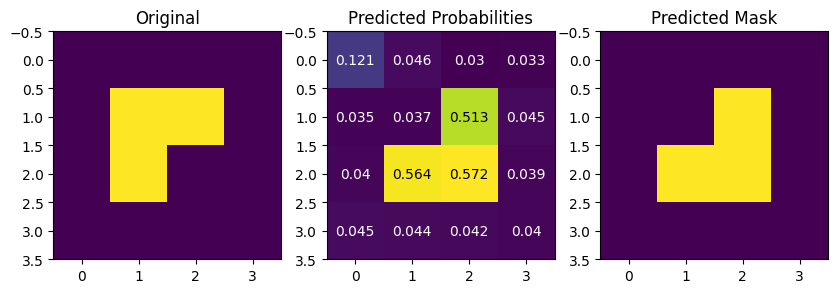

In [99]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

Проверяем на данном примере:

In [100]:
bce_loss_score = bce_loss(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_true_score = bce_true(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu())
bce_torch_score = bce_torch(torch.sigmoid(dummpy_sample['logits'].cpu()), dummpy_sample['labels'].cpu().float())
bce_torch_with_logits_score = bce_torch_with_logits(dummpy_sample['logits'].cpu(), dummpy_sample['labels'].cpu().float())
assert np.isclose(bce_loss_score, bce_torch_score)
assert np.isclose(bce_loss_score, bce_torch_with_logits_score)
assert np.isclose(bce_true_score, bce_torch_score)
assert np.isclose(bce_true_score, bce_torch_with_logits_score)

## SegNet [2 балла]

Ваше задание здесь состоит в том, чтобы реализовать SegNet архитектуру.

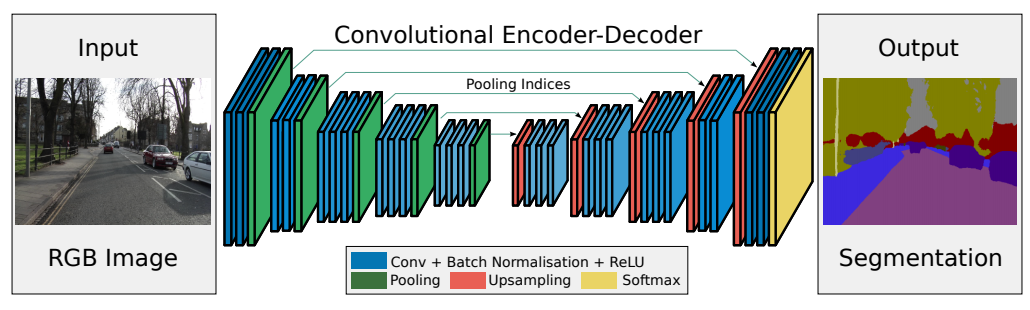

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

Внимательно посмотрите из чего состоит модель и для чего выбраны те или иные блоки.

In [101]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torch.optim as optim
from time import time

from matplotlib import rcParams
rcParams['figure.figsize'] = (15,4)

Хорошие ресурсы по SegNet архитектуре:
1. https://medium.com/@nikdenof/segnet-from-scratch-using-pytorch-3fe9b4527239


In [102]:
class SegNet(nn.Module):
    def __init__(self):
        super().__init__()

        # VGG-16 architecture
        self.enc_conv0 = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU())
        self.pool0 = nn.MaxPool2d(2,2,return_indices=True)  # 256 -> 128

        self.enc_conv1 = nn.Sequential(nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU())
        self.pool1 = nn.MaxPool2d(2,2,return_indices=True) # 128 -> 64

        self.enc_conv2 = nn.Sequential(nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU())
        self.pool2 = nn.MaxPool2d(2,2,return_indices=True) # 64 -> 32

        self.enc_conv3 = nn.Sequential(nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU())
        self.pool3 = nn.MaxPool2d(2,2,return_indices=True) # 32 -> 16

        # bottleneck
        self.bottleneck_conv = nn.Sequential(nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU())

        # decoder (upsampling)
        self.upsample0 = nn.MaxUnpool2d(kernel_size=2, stride=2) # 16 -> 32
        self.dec_conv0 = nn.Sequential(nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU())
        self.upsample1 = nn.MaxUnpool2d(kernel_size=2, stride=2) # 32 -> 64
        self.dec_conv1 = nn.Sequential(nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU())
        self.upsample2 = nn.MaxUnpool2d(kernel_size=2, stride=2) # 64 -> 128
        self.dec_conv2 = nn.Sequential(nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU())
        self.upsample3 = nn.MaxUnpool2d(kernel_size=2, stride=2) # 128 -> 256
        self.dec_conv3 = nn.Sequential(nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, padding=1))


    def forward(self, x):
        e0, ind0 = self.pool0(self.enc_conv0(x))
        e1, ind1 = self.pool1(self.enc_conv1(e0))
        e2, ind2 = self.pool2(self.enc_conv2(e1))
        e3, ind3 = self.pool3(self.enc_conv3(e2))

        # bottleneck
        b = self.bottleneck_conv(e3)

        # decoder
        d0 = self.dec_conv0(self.upsample0(b,ind3))
        d1 = self.dec_conv1(self.upsample1(d0,ind2))
        d2 = self.dec_conv2(self.upsample2(d1,ind1))
        d3 = self.dec_conv3(self.upsample3(d2,ind0))

        return d3

In [103]:
 segnet_model = SegNet().to(device)

## Тренировка [1 балл]

Напишите функцию для обучения модели.

In [104]:
from tqdm.notebook import tqdm

In [105]:
def train(model, train_dataloader, valid_dataloader, optimizer, criterion, num_epochs, device):
    for epoch in range(num_epochs):

        model.train()
        running_loss = 0.0
        for images, masks in tqdm(train_dataloader):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_dataloader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, masks in valid_dataloader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)
                val_loss += loss.item()

        val_loss /= len(valid_dataloader)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")

Обучите модель **SegNet**. В качестве оптимайзера можно взять Adam.

In [106]:
optimizer = torch.optim.Adam(segnet_model.parameters(), lr=1e-3)
criterion = bce_loss

In [107]:
train(segnet_model, train_dataloader, valid_dataloader, optimizer, criterion, num_epochs=20, device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [1/20], Train Loss: 1089681.3906, Validation Loss: 1106113.3750


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [2/20], Train Loss: 725644.1250, Validation Loss: 3208351.8750


  0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch [18/20], Train Loss: 268348.1758, Validation Loss: 573409.1562


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [19/20], Train Loss: 247518.5078, Validation Loss: 293611.3750


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [20/20], Train Loss: 236481.5508, Validation Loss: 354645.4219


## Инференс [1 балл]

После обучения модели напишите фукнцию теста, воспользуйтесь лучшим чекпоинтом и протестируйте работу модели на тестовой выборке.

In [108]:
def test(model, test_dataloader, device, iou):
  model.eval()
  iou.reset()
  iou_scores = []
  with torch.no_grad():
    for images, masks in tqdm(test_dataloader):

      images, masks = images.to(device), masks.to(device)

      outputs = model(images)

      predicted_masks = (outputs > 0.5).float()

      iou_score = iou(predicted_masks, masks)
      iou_scores.append(iou_score.item())


  mean_iou_score = sum(iou_scores) / len(iou_scores)

  return mean_iou_score

In [109]:
test_score = test(segnet_model, test_dataloader, device, iou_score)
test_score

  0%|          | 0/2 [00:00<?, ?it/s]

0.7442677915096283

In [110]:
import torch
import gc

if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()

26625

# Мир других лоссов!

## Дополнительные функции потерь [2 балла]

В данном разделе вам потребуется имплементировать две функции потерь: DICE и Focal loss.

### Dice Loss

**1. Dice coefficient:** Учитывая две маски $X$ и $Y$, общая метрика для измерения расстояния между этими двумя масками задается следующим образом:

$$D(X,Y)=\frac{2|X\cap Y|}{|X|+|Y|}$$

В терминах матрицы ошибок она будет считаться следующим образом:

$$D(X,Y) = \frac{2TP}{2TP + FP + FN}$$

Эта функция не является дифференцируемой, но это необходимое свойство для градиентного спуска. В данном случае мы можем приблизить его с помощью:

$$\mathcal L_D(X,Y) = 1- D(X, Y)$$

**Hints** (!):

1. Не забудьте подумать о численной нестабильности, возникающей в математической формуле при ситуации, когда $\frac{0}{0}$, т.е. вам нужно добавить очень маленькое число, например $\epsilon = 1e^{-8}$, в обе части дроби при подсчете $D(X,Y)$:

$$D(X,Y) = \frac{2TP + ϵ}{2TP + FP + FN + ϵ}$$

2. Dice метрика(!), не лосс, считается похожим образом как IoU:

    2.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    2.2. Фиксируем порог, например threshold=0.5, и всему что ниже порога ставим значение 0, всему что выше 1. Получаем предсказанную маску из 0 и 1.

    2.3. Считаем TP, FP, FN

    2.4. Считаем DICE метрику по формуле

Вы можете прописать для себя функцию `dice_score()` и сравнить с результатами работы функции из библиотеки `torchmetrics`.

3. Но с метрикой есть проблема, что она не дифференцируема, и если вы захотите просто взять и прописать `dice_loss` = 1 - `dice_score`, Pytorch поругается на вас и скажет, что это недифференцируемая метрика. Чтобы посчитать dice_loss делаем следующие шаги:

    3.1. На вход вам приходят logits, т.е. значения от $-∞$ до $∞$. Их переводим в вероятности от 0 до 1 при помощи функции Sigmoid.

    3.2. Здесь нам уже не нужно фиксировать порог, мы просто работаем с вероятностями. Значения вероятностей дифференцируемы и через них будут протекать градиенты.

    3.3. Считаем TP, FP, FN также как и в Dice метрике, только вместо маски, подаем вероятности.

    3.4. Считаем DICE метрику по формуле

    3.5. Считаем лосс как Loss = 1 - DICE

Итак, давайте сначала пропишем dice_score.

In [111]:
def dice_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    '''
    Это именно метрика, не лосс.
    '''
    prob=torch.sigmoid(logits)
    pred=(prob>threshold).float()

    tp = torch.sum(pred*labels)
    fp = torch.sum(pred) - tp
    fn = torch.sum(labels) - tp

    eps = 1e-8

    score=(2*tp + eps) / (2*tp + fp + fn + eps)

    return score

Проверим на корректность функцию dice_score:

In [112]:
from torchmetrics.segmentation import DiceScore

dice = DiceScore(average='micro', num_classes=1).to(device)
dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int))

tensor(0.4244, device='cuda:0')

In [113]:
# assert dice(dummpy_sample['logits'].sigmoid(), dummpy_sample['labels'].to(int)) == dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

In [114]:
dice_score(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.6667, device='cuda:0')

Давайте теперь пропишем лосс и воспользуемся библиотекой `segmentation-models-pytorch`, чтобы убедиться в корректности нашей функции.

In [115]:
def dice_loss(logits: torch.Tensor, labels: torch.Tensor):

    '''
    Это лосс.
    '''
    prob=torch.sigmoid(logits)

    tp = torch.sum(prob*labels)
    fp = torch.sum(prob) - tp
    fn = torch.sum(labels) - tp

    eps = 1e-8

    dice=(2*tp + eps) / (2*tp + fp + fn + eps)

    loss=1-dice

    return loss.mean()

Проверка на корректность:

In [116]:
!pip install segmentation-models-pytorch

In [117]:
from segmentation_models_pytorch.losses import DiceLoss
dice_loss_torch = DiceLoss(mode='binary')
dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'])

tensor(0.5756, device='cuda:0')

In [118]:
assert dice_loss_torch(dummpy_sample['logits'], dummpy_sample['labels'].to(int)) == dice_loss(dummpy_sample['logits'], dummpy_sample['labels'])

### Focal Loss

[**2. Focal loss:**](https://arxiv.org/pdf/1708.02002.pdf)

Окей, мы уже с вами умеем делать BCE loss:

$$\mathcal L_{BCE}(y, \hat y) = -\sum_i \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Проблема с этой потерей заключается в том, что она имеет тенденцию приносить пользу классу **большинства** (фоновому) по отношению к классу **меньшинства** ( переднему). Поэтому обычно применяются весовые коэффициенты к каждому классу:

$$\mathcal L_{wBCE}(y, \hat y) = -\sum_i \alpha_i\left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

Традиционно вес $\alpha_i$ определяется как обратная частота класса этого пикселя $i$, так что наблюдения миноритарного класса весят больше по отношению к классу большинства.


Из оригинальной статьи по [Focal Loss](https://arxiv.org/pdf/1708.02002.pdf):

$$p_t = \sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)$$

$$\mathcal L_{focal}(y, \hat y) = (1 - p_t)^{\gamma} \mathcal L_{BCE}(y_i, \hat y_i).$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - p_t)^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

$$\mathcal L_{focal}(y, \hat y) = -\sum_i (1 - (\sigma(\hat y_i)y_i + (1 - \sigma(\hat y_i)) (1-y_i)))^{\gamma} \left[y_i\log\sigma(\hat y_i) + (1-y_i)\log(1-\sigma(\hat y_i))\right].$$

In [166]:
def focal_loss(y_pred, y_real, eps = 1e-8, gamma = 2):
    prob = torch.sigmoid(y_pred)

    pt = prob * y_real + (1 - prob) * (1 - y_real)

    loss = -(1 - pt) ** gamma * (y_real * torch.log(prob + eps) + (1 - y_real) * torch.log(1 - prob + eps))

    return loss.sum()

Проверка корректности функции:

In [160]:
from torchvision.ops import sigmoid_focal_loss
sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum')

tensor(3.6161, device='cuda:0')

In [159]:
focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0)

tensor(3.6161, device='cuda:0')

In [133]:
assert torch.allclose(
    sigmoid_focal_loss(dummpy_sample['logits'], dummpy_sample['labels'], alpha=-1, gamma=2, reduction='sum'),
    focal_loss(dummpy_sample['labels'], dummpy_sample['logits'], gamma=2.0),
    atol=1e-6
)


## Обучите SegNet на новых лоссах

**Задание**: обучите SegNet на новых лоссах и сравните все три лосса:
*   При каком лоссе модель сходится быстрее?
*   При каком лоссе модель выдает наилучшую метрику?

Напишите развернутый ответ на вопросы.



In [134]:
model_dice = SegNet().to(device)

In [135]:
#dice_loss
criterion = dice_loss
optimizer = torch.optim.Adam(model_dice.parameters(), lr=1e-3)
train(model_dice, train_dataloader, valid_dataloader, optimizer, criterion, num_epochs=20, device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [1/20], Train Loss: 0.6094, Validation Loss: 0.6071


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [2/20], Train Loss: 0.5155, Validation Loss: 0.6078


  0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch [18/20], Train Loss: 0.1212, Validation Loss: 0.1779


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [19/20], Train Loss: 0.1172, Validation Loss: 0.1482


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [20/20], Train Loss: 0.1144, Validation Loss: 0.2479


In [136]:
test_score = test(model_dice, test_dataloader, device, iou_score)
test_score

  0%|          | 0/2 [00:00<?, ?it/s]

0.5958513617515564

In [167]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()

3065

In [168]:
def focal_loss(y_pred, y_real, eps = 1e-8, gamma = 2):
    prob = torch.sigmoid(y_pred)

    pt = prob * y_real + (1 - prob) * (1 - y_real)

    loss = -(1 - pt) ** gamma * (y_real * torch.log(prob + eps) + (1 - y_real) * torch.log(1 - prob + eps))

    return loss.sum()

In [169]:
model_focal = SegNet().to(device)

In [170]:
#focal_loss
criterion = focal_loss

optimizer = torch.optim.Adam(model_focal.parameters(), lr=1e-3)
train(model_focal, train_dataloader, valid_dataloader, optimizer, criterion, num_epochs=20, device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [1/20], Train Loss: 314764.5234, Validation Loss: 281824.3125


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [2/20], Train Loss: 212226.8828, Validation Loss: 262335.1562


  0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch [18/20], Train Loss: 90377.2812, Validation Loss: 161518.1172


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [19/20], Train Loss: 80487.9883, Validation Loss: 130701.0234


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [20/20], Train Loss: 91981.4795, Validation Loss: 109394.9922


In [171]:
test_score = test(model_focal, test_dataloader, device, iou_score)
test_score

  0%|          | 0/2 [00:00<?, ?it/s]

0.6980076134204865

In [156]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()

144

# Новая модель!

## U-Net [2 балла]

[**U-Net**](https://arxiv.org/abs/1505.04597) — это архитектура нейронной сети, которая получает изображение и выводит его. Первоначально он был задуман для семантической сегментации (как мы ее будем использовать), но он настолько успешен, что с тех пор используется в других контекстах. Получая на вход медицинское изображение, он выведет изображение в оттенках серого, где интенсивность каждого пикселя зависит от вероятности того, что этот пиксель принадлежит интересующей нас области.

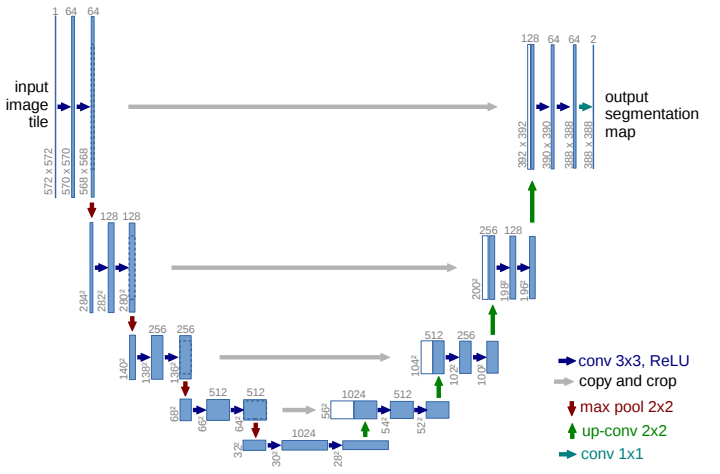

У нас в архитектуре все так же существует энкодер и декодер, как в **SegNet**, но отличительной особеностью данной модели являются *skip-conenctions*, соединяющие части декодера и энкодера. То есть для того чтобы передать на вход декодера тензор, мы конкатенируем симметричный выход с энкодера и выход предыдущего слоя декодера.

* Ronneberger, Olaf, Philipp Fischer, and Thomas Brox. "[U-Net: Convolutional networks for biomedical image segmentation.](https://arxiv.org/pdf/1505.04597.pdf)" International Conference on Medical image computing and computer-assisted intervention. Springer, Cham, 2015.

In [142]:
import torch.nn.functional as F
import torch.nn as nn

In [143]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # VGG-16 architecture
        self.enc_conv0 = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU())
        self.pool0 = nn.MaxPool2d(2,2)  # 256 -> 128

        self.enc_conv1 = nn.Sequential(nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU())
        self.pool1 = nn.MaxPool2d(2,2) # 128 -> 64

        self.enc_conv2 = nn.Sequential(nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU())
        self.pool2 = nn.MaxPool2d(2,2) # 64 -> 32

        self.enc_conv3 = nn.Sequential(nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU())
        self.pool3 = nn.MaxPool2d(2,2) # 32 -> 16

        # bottleneck
        self.bottleneck_conv = nn.Sequential(nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                                             nn.BatchNorm2d(512),
                                             nn.ReLU(),
                                             nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
                                             nn.BatchNorm2d(512),
                                             nn.ReLU())

        # decoder (upsampling)
        self.upsample0 = nn.ConvTranspose2d(512, 512, 2, stride=2) # 16 -> 32
        self.dec_conv0 = nn.Sequential(nn.Conv2d(in_channels=512*2, out_channels=512, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(512),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU())
        self.upsample1 = nn.ConvTranspose2d(256, 256, 2, stride=2) # 32 -> 64
        self.dec_conv1 = nn.Sequential(nn.Conv2d(in_channels=256*2, out_channels=256, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(256),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU())
        self.upsample2 = nn.ConvTranspose2d(128, 128, 2, stride=2) # 64 -> 128
        self.dec_conv2 = nn.Sequential(nn.Conv2d(in_channels=128*2, out_channels=128, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(128),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU())
        self.upsample3 = nn.ConvTranspose2d(64, 64, 2, stride=2) # 128 -> 256
        self.dec_conv3 = nn.Sequential(nn.Conv2d(in_channels=64*2, out_channels=64, kernel_size=3, padding=1),
                                       nn.BatchNorm2d(64),
                                       nn.ReLU(),
                                       nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, padding=1))

    def forward(self, x):
        e0 = self.enc_conv0(x)
        e0_p = self.pool0(e0)

        e1 = self.enc_conv1(e0_p)
        e1_p = self.pool1(e1)

        e2 = self.enc_conv2(e1_p)
        e2_p = self.pool2(e2)

        e3 = self.enc_conv3(e2_p)
        e3_p = self.pool3(e3)

        b = self.bottleneck_conv(e3_p)

        u0 = self.upsample0(b)
        d0 = self.dec_conv0(torch.cat([u0, e3], dim=1))

        u1 = self.upsample1(d0)
        d1 = self.dec_conv1(torch.cat([u1, e2], dim=1))

        u2 = self.upsample2(d1)
        d2 = self.dec_conv2(torch.cat([u2, e1], dim=1))

        u3 = self.upsample3(d2)
        d3 = self.dec_conv3(torch.cat([u3, e0], dim=1))

        return d3


In [144]:
unet_model = UNet().to(device)

## Обучите UNet

Задание: обучите UNet на всех трех лоссах: BCE, Dice, Focal и сравните результаты с SegNet:
*   Какая модель дает лучшие значения по метрике?
*   Какая модель дает лучшие значения по лоссам?
*   Какая модель обучается быстрее?
*   Сравните визуально результаты SegNet и UNet.

Напишите развернутый ответ на вопросы.



In [145]:
#bce_loss
criterion = bce_loss
optimizer = torch.optim.Adam(unet_model.parameters(), lr=1e-3)
train(unet_model, train_dataloader, valid_dataloader, optimizer, criterion, num_epochs=20, device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [1/20], Train Loss: 798697.7812, Validation Loss: 1006853.6562


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [2/20], Train Loss: 563701.1875, Validation Loss: 921470.7188


  0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch [18/20], Train Loss: 239204.7422, Validation Loss: 627028.5625


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [19/20], Train Loss: 266002.4375, Validation Loss: 633550.3438


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [20/20], Train Loss: 239297.1719, Validation Loss: 385172.0000


In [146]:
test_score = test(unet_model, test_dataloader, device, iou_score)
test_score

  0%|          | 0/2 [00:00<?, ?it/s]

0.7257815003395081

In [147]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()

160

In [148]:
#dice_loss
unet_model_dice = UNet().to(device)
criterion = dice_loss
optimizer = torch.optim.Adam(unet_model_dice.parameters(), lr=1e-3)
train(unet_model_dice, train_dataloader, valid_dataloader, optimizer, criterion, num_epochs=20, device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [1/20], Train Loss: 0.4349, Validation Loss: 0.6070


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [2/20], Train Loss: 0.3025, Validation Loss: 0.6782


  0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch [18/20], Train Loss: 0.1177, Validation Loss: 0.1434


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [19/20], Train Loss: 0.1032, Validation Loss: 0.1713


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [20/20], Train Loss: 0.1290, Validation Loss: 0.1881


In [149]:
test_score = test(unet_model_dice, test_dataloader, device, iou_score)
test_score

  0%|          | 0/2 [00:00<?, ?it/s]

0.6600375771522522

In [176]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()

144

In [177]:
#focal_loss
unet_model_focal= UNet().to(device)
criterion = focal_loss
optimizer = torch.optim.Adam(unet_model_focal.parameters(), lr=1e-3)
train(unet_model_focal, train_dataloader, valid_dataloader, optimizer, criterion, num_epochs=20, device=device)

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [1/20], Train Loss: 215046.4766, Validation Loss: 261020.0312


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [2/20], Train Loss: 134542.4648, Validation Loss: 260946.4609


  0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch [18/20], Train Loss: 72926.0117, Validation Loss: 124936.4375


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [19/20], Train Loss: 62005.6484, Validation Loss: 94799.1055


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch [20/20], Train Loss: 64835.9443, Validation Loss: 121604.6172


In [178]:
test_score = test(unet_model_focal, test_dataloader, device, iou_score)
test_score

  0%|          | 0/2 [00:00<?, ?it/s]

0.7653626799583435

**Для SegNet наилучший результат для bce loss. Наихудший - у dice loss. Скорость обучения примерно одинакова.**

**У UNet лучший результат показал focal loss, наихудший - у dice loss. Скорость обучения одинакова, но UNet обучается дольше SegNet.**